# 时间序列分析

本教程将学习时间序列数据的分析方法。

## 1. 导入必要的库

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 2. 创建时间序列数据

In [2]:
# 创建日期范围
date_rng = pd.date_range(start='2024-01-01', end='2024-03-31', freq='D')

# 创建模拟数据（包含趋势和季节性）
np.random.seed(42)
trend = np.arange(len(date_rng)) * 0.1
seasonality = 10 * np.sin(2 * np.pi * date_rng.day / 7)  # 周季节性
noise = np.random.normal(0, 2, len(date_rng))

# 组合数据
sales = 100 + trend + seasonality + noise

# 创建DataFrame
df = pd.DataFrame({'date': date_rng, 'sales': sales})
df.set_index('date', inplace=True)

print('数据形状:', df.shape)
print('前10行数据:')
print(df.head(10))

数据形状: (91, 1)
前10行数据:
                 sales
date                  
2024-01-01  108.811743
2024-01-02  109.572751
2024-01-03  105.834214
2024-01-04   99.007222
2024-01-05   90.182414
2024-01-06   92.213411
2024-01-07  103.758426
2024-01-08  110.053184
2024-01-09  109.610330
2024-01-10  106.323957


## 3. 时间序列可视化

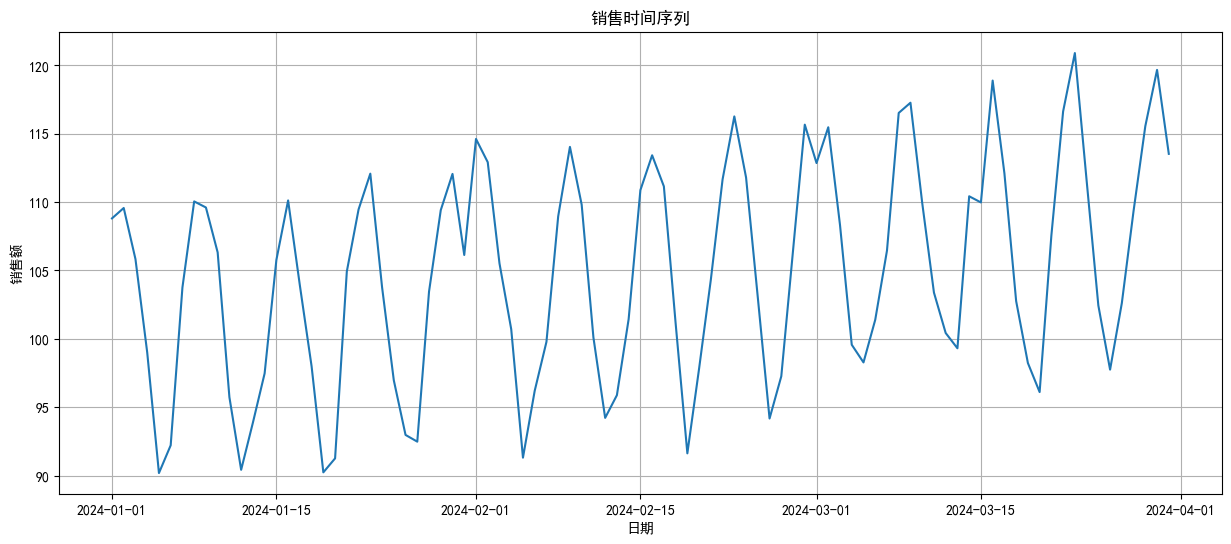

In [3]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['sales'])
plt.title('销售时间序列')
plt.xlabel('日期')
plt.ylabel('销售额')
plt.grid(True)
plt.show()

## 4. 时间序列分解

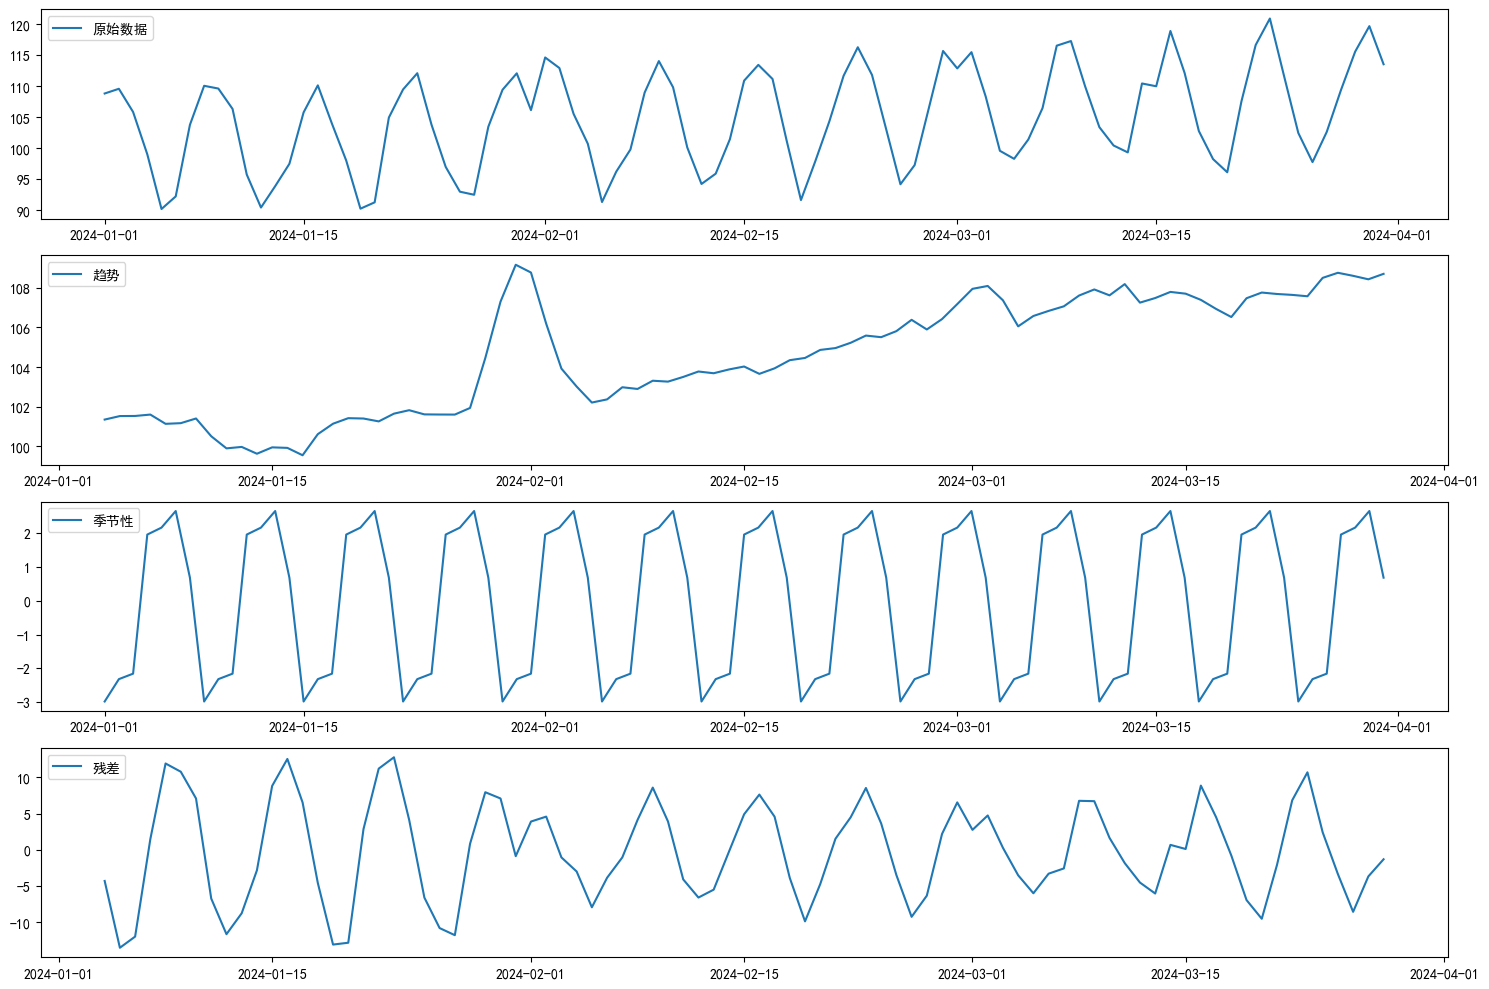

In [4]:
# 时间序列分解
result = seasonal_decompose(df['sales'], model='additive', period=7)

# 可视化分解结果
plt.figure(figsize=(15, 10))

plt.subplot(411)
plt.plot(df['sales'], label='原始数据')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(result.trend, label='趋势')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(result.seasonal, label='季节性')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(result.resid, label='残差')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 5. 移动平均分析

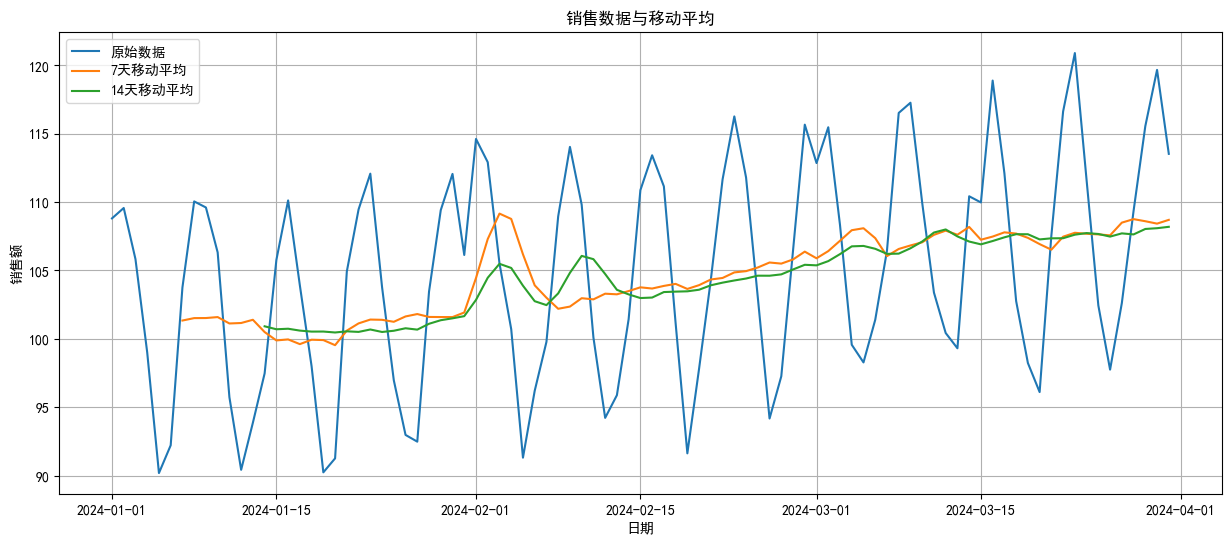

In [5]:
# 计算移动平均
df['MA7'] = df['sales'].rolling(window=7).mean()  # 7天移动平均
df['MA14'] = df['sales'].rolling(window=14).mean()  # 14天移动平均

# 可视化移动平均
plt.figure(figsize=(15, 6))
plt.plot(df['sales'], label='原始数据')
plt.plot(df['MA7'], label='7天移动平均')
plt.plot(df['MA14'], label='14天移动平均')
plt.title('销售数据与移动平均')
plt.xlabel('日期')
plt.ylabel('销售额')
plt.legend()
plt.grid(True)
plt.show()

## 6. 时间序列预测（ARIMA模型）

In [6]:
# 分割训练集和测试集
train_size = int(len(df) * 0.8)
train, test = df['sales'][:train_size], df['sales'][train_size:]

print(f'训练集大小: {len(train)}')
print(f'测试集大小: {len(test)}')

训练集大小: 72
测试集大小: 19


f:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
f:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
f:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


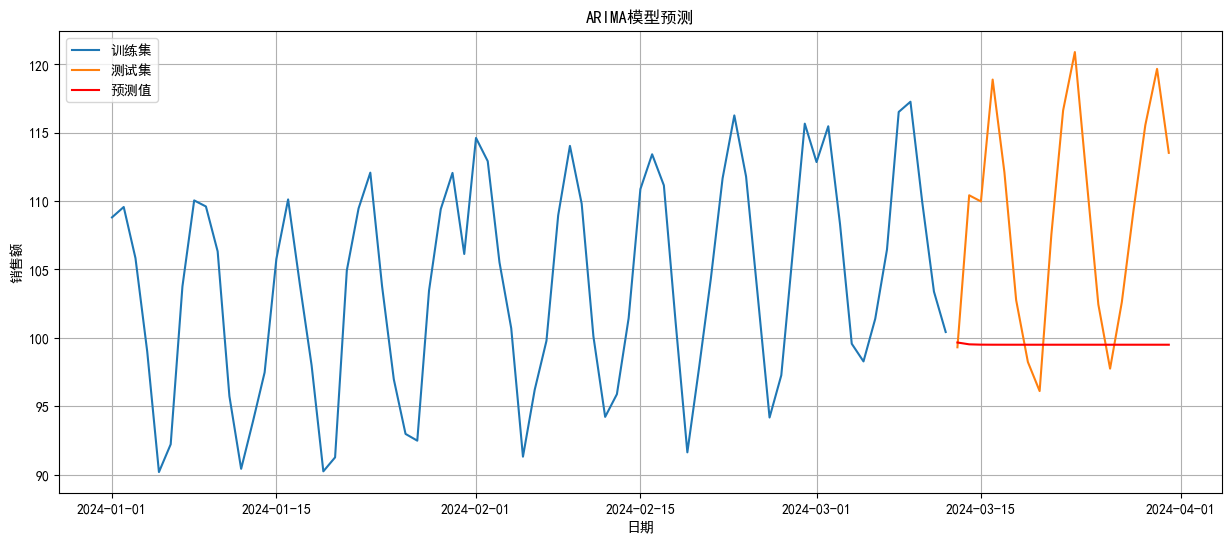

RMSE: 11.99


In [7]:
# 拟合ARIMA模型
try:
    model = ARIMA(train, order=(1, 1, 1))  # ARIMA(p, d, q)
    model_fit = model.fit()
    
    # 预测
    forecast = model_fit.forecast(steps=len(test))
    
    # 可视化预测结果
    plt.figure(figsize=(15, 6))
    plt.plot(train.index, train, label='训练集')
    plt.plot(test.index, test, label='测试集')
    plt.plot(test.index, forecast, label='预测值', color='red')
    plt.title('ARIMA模型预测')
    plt.xlabel('日期')
    plt.ylabel('销售额')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 评估模型
    from sklearn.metrics import mean_squared_error
    rmse = np.sqrt(mean_squared_error(test, forecast))
    print(f'RMSE: {rmse:.2f}')
except Exception as e:
    print(f'模型拟合失败: {e}')
    print('可能需要安装statsmodels库: pip install statsmodels')

## 7. 时间序列特征工程

In [8]:
# 创建时间特征
df_features = df.copy()
df_features['day_of_week'] = df_features.index.dayofweek  # 星期几
df_features['day_of_month'] = df_features.index.day  # 当月第几天
df_features['week_of_month'] = (df_features.index.day - 1) // 7 + 1  # 当月第几周
df_features['is_weekend'] = (df_features.index.dayofweek >= 5).astype(int)  # 是否周末

# 创建滞后特征
df_features['lag1'] = df_features['sales'].shift(1)  # 滞后1天
df_features['lag7'] = df_features['sales'].shift(7)  # 滞后7天

# 创建滚动统计特征
df_features['rolling_mean_7'] = df_features['sales'].rolling(window=7).mean()
df_features['rolling_std_7'] = df_features['sales'].rolling(window=7).std()

print('特征工程后的数据:')
print(df_features.tail())

特征工程后的数据:
                 sales         MA7        MA14  day_of_week  day_of_month  \
date                                                                        
2024-03-27  102.612489  108.500633  107.715893            2            27   
2024-03-28  109.357502  108.757325  107.639337            3            28   
2024-03-29  115.558794  108.603933  108.037906            4            29   
2024-03-30  119.675814  108.428326  108.093815            5            30   
2024-03-31  113.532992  108.704139  108.195248            6            31   

            week_of_month  is_weekend        lag1        lag7  rolling_mean_7  \
date                                                                            
2024-03-27              4           0   97.747207   96.106547      108.500633   
2024-03-28              4           0  102.612489  107.560656      108.757325   
2024-03-29              5           0  109.357502  116.632540      108.603933   
2024-03-30              5           1  115.55